In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 11,
    "axes.titlesize": 13,
})

np.random.seed(42)
torch.manual_seed(42)

print("Ready.")

Ready.


---
# 1) Optimization Algorithms

All modern deep learning optimizers are variants of **stochastic gradient descent**.

## 1.1 Vanilla SGD
The simplest update rule:

$$\theta_{t+1} = \theta_t - \alpha \cdot g_t, \quad g_t = \nabla_\theta {L}(\theta_t; x_i, y_i)$$

The gradient $g_t$ is computed on a mini-batch (or single example), introducing noise that helps escape local minima but also causes oscillation.

In [ ]:
class VanillaSGD:
    """Vanilla stochastic gradient descent."""

    def __init__(self, params, lr=0.01):
        self.lr = lr
        self.params = params

    def step(self, grads):
        for key in self.params:
            self.params[key] -= self.lr * grads[key]


print("VanillaSGD defined.")

VanillaSGD defined.


---
## 1.2 SGD with Momentum

Momentum accumulates a velocity vector in the direction of persistent gradients:

$$v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot g_t$$
$$\theta_{t+1} = \theta_t - \alpha \cdot v_t$$

where $\beta \approx 0.9$ is the momentum coefficient.

**Derivation — why it helps:**

Expanding the recursion:

$$v_t = (1-\beta) \sum_{i=0}^{t} \beta^{t-i} g_i$$

This is an **exponentially weighted moving average** of past gradients. Gradients that consistently point in the same direction accumulate; oscillating components cancel out. The effective step size in consistent directions is amplified by $\frac{1}{1-\beta}$.

Physically: $v$ is velocity, $\beta$ is friction, $g$ is force. The parameter "rolls downhill" with inertia.

> **Note:** Some implementations use $v_t = \beta v_{t-1} + g_t$ (without $1-\beta$), which is equivalent with a rescaled learning rate $\alpha' = \alpha(1-\beta)$.

In [ ]:
class MomentumSGD:
    """SGD with momentum."""

    def __init__(self, params, lr=0.01, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.params = params
        self.v = {key: np.zeros_like(val) for key, val in params.items()}

    def step(self, grads):
        for key in self.params:

            # Exponential moving average of gradients
            # self.v is the previous gradient
            self.v[key] = self.beta * self.v[key] + (1 - self.beta) * grads[key]
            self.params[key] -= self.lr * self.v[key]


print("MomentumSGD defined.")

MomentumSGD defined.


---
## 1.3 RMSProp (Adaptive Learning Rates)

RMSProp (Hinton, unpublished lecture notes) adapts the learning rate **per parameter** based on the magnitude of recent gradients:

$$s_t = \beta \cdot s_{t-1} + (1 - \beta) \cdot g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{s_t} + \epsilon} \cdot g_t$$

**Derivation of the adaptive effect:**

$s_t$ is an EMA of squared gradients — a running estimate of $\mathbb{E}[g^2]$. Dividing by $\sqrt{s_t}$ normalizes each parameter's update by its RMS gradient magnitude:

- Parameters with large gradients → large $s_t$ → smaller effective LR → dampens oscillation
- Parameters with small gradients → small $s_t$ → larger effective LR → accelerates learning

This per-parameter adaptation is especially useful when different parameters have very different gradient scales (common in RNNs and with mixed feature scales).

In [ ]:
class RMSProp:
    """RMSProp optimizer."""

    def __init__(self, params, lr=0.001, beta=0.999, eps=1e-8):
        self.lr = lr
        self.beta = beta
        self.eps = eps
        self.params = params
        self.s = {key: np.zeros_like(val) for key, val in params.items()}

    def step(self, grads):
        for key in self.params:
            # EMA of squared gradients
            self.s[key] = self.beta * self.s[key] + (1 - self.beta) * grads[key] ** 2
            # Adaptive update: normalize by RMS of gradients
            self.params[key] -= self.lr * grads[key] / (np.sqrt(self.s[key]) + self.eps)


print("RMSProp defined.")

RMSProp defined.


---
## 1.4 Adam (Combining Momentum + RMSProp, Bias Correction Derivation)

Adam (Kingma & Ba, 2015) maintains both first and second moment estimates:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(first moment — mean)}$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(second moment — uncentered variance)}$$

In [ ]:
class Adam:
    """Adam optimizer with bias correction."""

    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.params = params
        self.t = 0
        self.m = {key: np.zeros_like(val) for key, val in params.items()}
        self.v = {key: np.zeros_like(val) for key, val in params.items()}

    def step(self, grads):
        self.t += 1
        for key in self.params:

            # First moment (momentum)
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            # Second moment (RMSProp-like)
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2

            # Bias correction
            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            # Update
            self.params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


print("Adam defined.")

Adam defined.


---
## 1.5 AdamW (Decoupled Weight Decay)

**The problem with L2 + Adam:**

In vanilla SGD, L2 regularization ($\lambda W$ added to gradient) and weight decay ($\lambda W$ subtracted from weights) are equivalent:

$$W \leftarrow W - \alpha(g + \lambda W) = (1 - \alpha\lambda)W - \alpha g$$

But in Adam, the gradient is divided by $\sqrt{\hat{v}}$. With L2 regularization:

$$W \leftarrow W - \frac{\alpha}{\sqrt{\hat{v}} + \epsilon}(g + \lambda W)$$

The weight decay is **also** scaled by the adaptive learning rate — heavy parameters with large gradients get **less** regularization, which is backwards!

**AdamW** (Loshchilov & Hutter, 2019) decouples weight decay from the adaptive gradient step:

$$W \leftarrow W - \frac{\alpha}{\sqrt{\hat{v}} + \epsilon} \hat{m} - \alpha \lambda W$$

Now weight decay is applied **uniformly** to all weights, regardless of gradient magnitude.

In [ ]:
class AdamW:
    """AdamW optimizer — Adam with decoupled weight decay."""

    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.wd = weight_decay
        self.params = params
        self.t = 0
        self.m = {key: np.zeros_like(val) for key, val in params.items()}
        self.v = {key: np.zeros_like(val) for key, val in params.items()}

    def step(self, grads):
        self.t += 1
        for key in self.params:
            # Decoupled weight decay — applied directly to weights
            self.params[key] *= (1 - self.lr * self.wd)

            # Standard Adam moment updates (on raw gradients, not L2-modified)
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2

            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            self.params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


print("AdamW defined. Weight decay is decoupled from the adaptive gradient step.")

AdamW defined. Weight decay is decoupled from the adaptive gradient step.


---
## 1.6 Comparison:

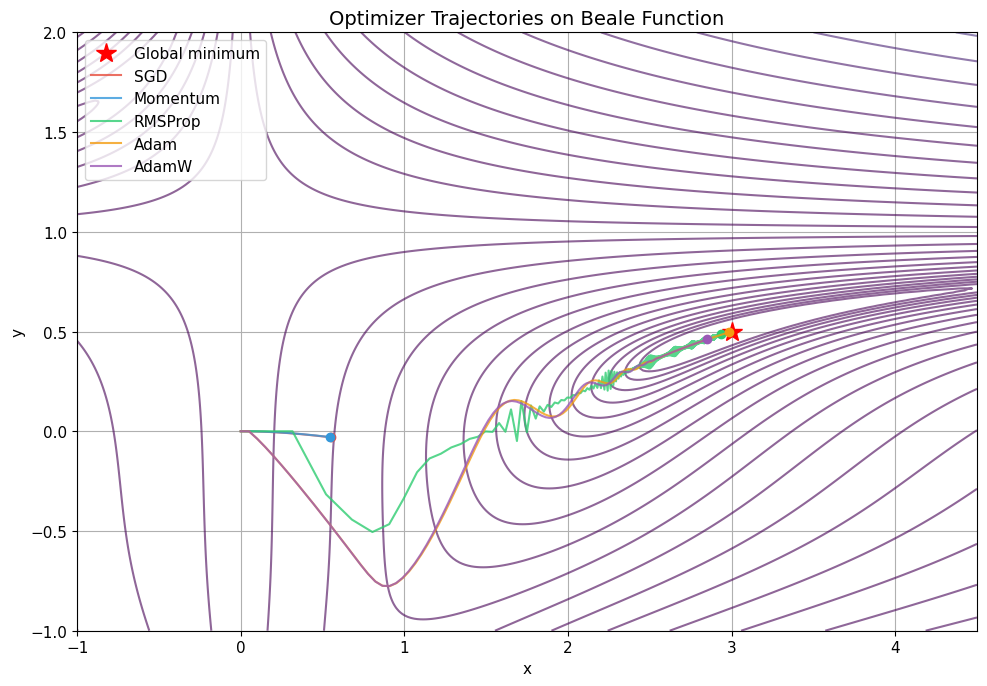

In [ ]:
def beale(x, y):
    return (1.5 - x + x * y) ** 2 + (2.25 - x + x * y**2) ** 2 + (2.625 - x + x * y**3) ** 2


def beale_grad(x, y):
    dx = (2 * (1.5 - x + x * y) * (-1 + y) +
          2 * (2.25 - x + x * y**2) * (-1 + y**2) +
          2 * (2.625 - x + x * y**3) * (-1 + y**3))
    dy = (2 * (1.5 - x + x * y) * x +
          2 * (2.25 - x + x * y**2) * 2 * x * y +
          2 * (2.625 - x + x * y**3) * 3 * x * y**2)
    return np.array([dx, dy])


def rosenbrock(x, y):
    return (1 - x) ** 2 + 100 * (y - x**2) ** 2


def rosenbrock_grad(x, y):
    dx = -2 * (1 - x) + 200 * (y - x**2) * (-2 * x)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])


def run_optimizer_2d(opt_class, grad_fn, x0, y0, n_steps, **opt_kwargs):
    """Run an optimizer on a 2D function and return trajectory."""
    params = {"w": np.array([x0, y0], dtype=float)}
    opt = opt_class(params, **opt_kwargs)
    trajectory = [params["w"].copy()]

    for _ in range(n_steps):
        g = grad_fn(params["w"][0], params["w"][1])
        opt.step({"w": g})
        trajectory.append(params["w"].copy())

    return np.array(trajectory)


def plot_optimizer_comparison(func, grad_fn, x0, y0, xlim, ylim, optimum, title, n_steps=300):
    """Plot optimizer trajectories on a 2D loss surface."""
    xx = np.linspace(xlim[0], xlim[1], 300)
    yy = np.linspace(ylim[0], ylim[1], 300)
    XX, YY = np.meshgrid(xx, yy)
    ZZ = func(XX, YY)

    optimizers = {
        "SGD": (VanillaSGD, {"lr": 0.0001}),
        "Momentum": (MomentumSGD, {"lr": 0.0001, "beta": 0.9}),
        "RMSProp": (RMSProp, {"lr": 0.01, "beta": 0.999}),
        "Adam": (Adam, {"lr": 0.05, "beta1": 0.9, "beta2": 0.999}),
        "AdamW": (AdamW, {"lr": 0.05, "beta1": 0.9, "beta2": 0.999, "weight_decay": 0.01}),
    }

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.contour(XX, YY, ZZ, levels=np.logspace(-1, 4, 30), cmap="viridis", alpha=0.6)
    ax.plot(*optimum, "r*", markersize=15, label="Global minimum")

    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
    for (name, (opt_cls, kwargs)), color in zip(optimizers.items(), colors):
        traj = run_optimizer_2d(opt_cls, grad_fn, x0, y0, n_steps, **kwargs)
        ax.plot(traj[:, 0], traj[:, 1], "-", lw=1.5, color=color, label=name, alpha=0.8)
        ax.plot(traj[-1, 0], traj[-1, 1], "o", color=color, markersize=6)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="upper left")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()


plot_optimizer_comparison(
    beale, beale_grad, x0=0.0, y0=0.0,
    xlim=(-1, 4.5), ylim=(-1, 2),
    optimum=(3, 0.5), title="Optimizer Trajectories on Beale Function",
    n_steps=500,
)

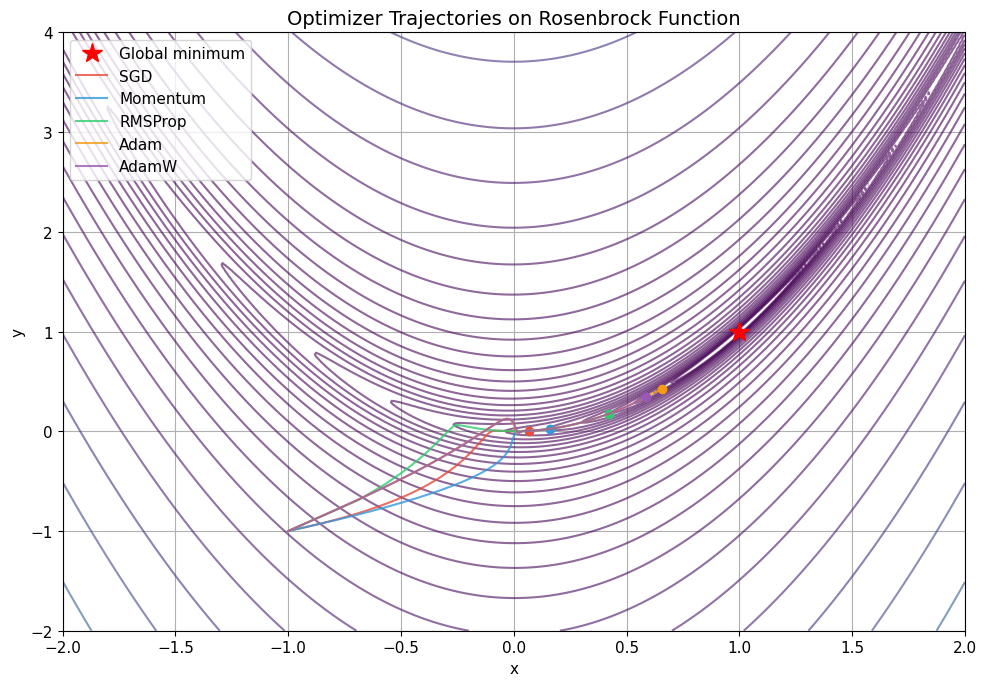

In [ ]:
plot_optimizer_comparison(
    rosenbrock, rosenbrock_grad, x0=-1.0, y0=-1.0,
    xlim=(-2, 2), ylim=(-2, 4),
    optimum=(1, 1), title="Optimizer Trajectories on Rosenbrock Function",
    n_steps=1000,
)

**Key observations:**
- **Vanilla SGD** moves slowly and can get stuck in flat regions
- **Momentum** accelerates in consistent gradient directions
- **RMSProp** adapts per-dimension, navigating narrow valleys better
- **Adam** combines both advantages — generally the fastest convergence
- **AdamW** behaves similarly to Adam but with better implicit regularization from decoupled weight decay

---
## 1.7 Learning Rate Schedules
A fixed learning rate is rarely optimal. LR schedules adjust $\alpha$ during training.

### 1.7.1 Step Decay

Reduce LR by a factor $\gamma$ every $T$ epochs:

$$\alpha_t = \alpha_0 \cdot \gamma^{\lfloor t / T \rfloor}$$

In [ ]:
def step_decay(epoch, lr_init=0.1, drop_factor=0.5, drop_every=30):
    return lr_init * drop_factor ** (epoch // drop_every)


print(f"Step decay at epoch 0: {step_decay(0):.4f}")
print(f"Step decay at epoch 30: {step_decay(30):.4f}")
print(f"Step decay at epoch 60: {step_decay(60):.4f}")

Step decay at epoch 0: 0.1000
Step decay at epoch 30: 0.0500
Step decay at epoch 60: 0.0250


### 1.7.2 Cosine Annealing

Smoothly decays LR following a cosine curve from $\alpha_{\max}$ to $\alpha_{\min}$:

$$\alpha_t = \alpha_{\min} + \frac{1}{2}(\alpha_{\max} - \alpha_{\min})\left(1 + \cos\left(\frac{t}{T_{\max}} \pi\right)\right)$$

This naturally slows down near the end, which helps the optimizer settle into a sharp minimum.

In [ ]:
def cosine_annealing(epoch, total_epochs=100, lr_max=0.1, lr_min=1e-5):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / total_epochs))


print(f"Cosine at epoch 0:  {cosine_annealing(0):.6f}")
print(f"Cosine at epoch 50: {cosine_annealing(50):.6f}")
print(f"Cosine at epoch 100: {cosine_annealing(100):.6f}")

Cosine at epoch 0:  0.100000
Cosine at epoch 50: 0.050005
Cosine at epoch 100: 0.000010


### 1.7.3 Warmup + Cosine

Start with a linear warmup from a small LR to $\alpha_{\max}$ over $T_w$ steps, then cosine decay. Used in virtually all modern transformer training (Vaswani et al., 2017; Devlin et al., 2019).

**Why warmup?** At initialization, activations and gradients are large/unstable. A large LR can cause divergence. Warmup allows the optimizer's second moment estimates to stabilize before ramping up.

In [ ]:
def warmup_cosine(epoch, total_epochs=100, warmup_epochs=10, lr_max=0.1, lr_min=1e-5):
    if epoch < warmup_epochs:
        # Linear warmup
        return lr_max * (epoch + 1) / warmup_epochs
    # Cosine decay after warmup
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))


print(f"Warmup+Cosine at epoch 0:  {warmup_cosine(0):.6f}")
print(f"Warmup+Cosine at epoch 5:  {warmup_cosine(5):.6f}")
print(f"Warmup+Cosine at epoch 10: {warmup_cosine(10):.6f}")
print(f"Warmup+Cosine at epoch 50: {warmup_cosine(50):.6f}")

Warmup+Cosine at epoch 0:  0.010000
Warmup+Cosine at epoch 5:  0.060000
Warmup+Cosine at epoch 10: 0.100000
Warmup+Cosine at epoch 50: 0.058687


### 1.7.4 Comparison

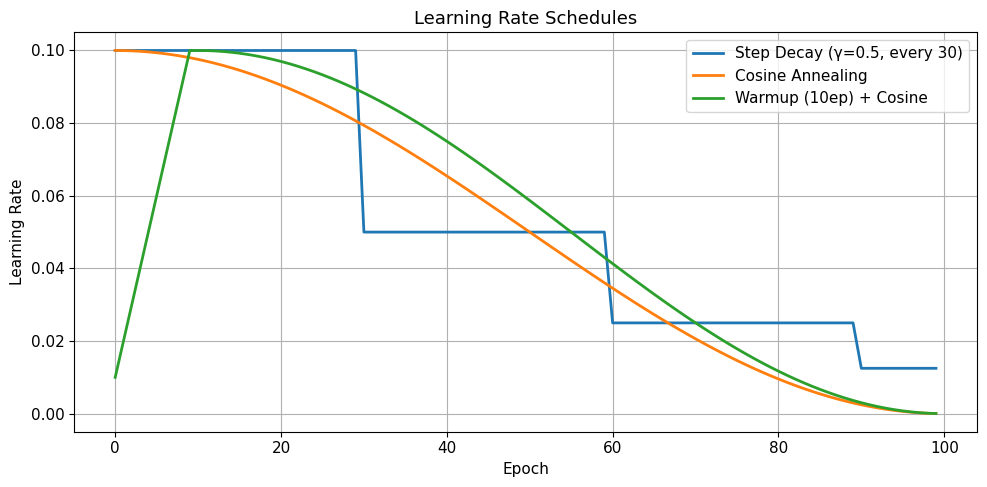

In [ ]:
total_epochs = 100
epochs = np.arange(total_epochs)

schedules = {
    "Step Decay (γ=0.5, every 30)": [step_decay(e, 0.1, 0.5, 30) for e in epochs],
    "Cosine Annealing": [cosine_annealing(e, total_epochs) for e in epochs],
    "Warmup (10ep) + Cosine": [warmup_cosine(e, total_epochs, 10) for e in epochs],
}

fig, ax = plt.subplots(figsize=(10, 5))
for name, lrs in schedules.items():
    ax.plot(epochs, lrs, lw=2, label=name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedules")
ax.legend()
plt.tight_layout()
plt.show()

---
## 1.8 Gradient Clipping

**Exploding gradients** can destabilize training, especially in RNNs and transformers. Gradient clipping caps the gradient magnitude.

**Clip by value:** Independently clip each gradient element to $[-\tau, \tau]$.

$$g_i \leftarrow \max(-\tau, \min(\tau, g_i))$$

**Clip by norm:** If the global gradient norm exceeds threshold $\tau$, rescale the entire gradient vector:

$$g \leftarrow g \cdot \frac{\tau}{\|g\|} \quad \text{if } \|g\| > \tau$$

Clipping by norm is generally preferred because it **preserves the gradient direction** while only limiting magnitude. Clipping by value can distort the gradient direction.

In [ ]:
def clip_by_value(grads, clip_val):
    """Clip each gradient element independently."""
    return {key: np.clip(g, -clip_val, clip_val) for key, g in grads.items()}


def clip_by_norm(grads, max_norm):
    """Rescale gradients if global norm exceeds max_norm."""
    total_norm = np.sqrt(sum(np.sum(g ** 2) for g in grads.values()))
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-8)
        return {key: g * scale for key, g in grads.items()}
    return grads


# Demo: gradient clipping
np.random.seed(0)
sample_grads = {
    "W1": np.random.randn(3, 3) * 10,
    "W2": np.random.randn(3, 3) * 5,
}

original_norm = np.sqrt(sum(np.sum(g ** 2) for g in sample_grads.values()))

clipped_val = clip_by_value(sample_grads, clip_val=5.0)
clipped_norm_result = clip_by_norm(sample_grads, max_norm=10.0)

norm_after_val = np.sqrt(sum(np.sum(g ** 2) for g in clipped_val.values()))
norm_after_norm = np.sqrt(sum(np.sum(g ** 2) for g in clipped_norm_result.values()))

print(f"Original gradient norm:        {original_norm:.4f}")
print(f"After clip_by_value(5.0):      {norm_after_val:.4f}")
print(f"After clip_by_norm(10.0):      {norm_after_norm:.4f}")

Original gradient norm:        40.0011
After clip_by_value(5.0):      15.7389
After clip_by_norm(10.0):      10.0000


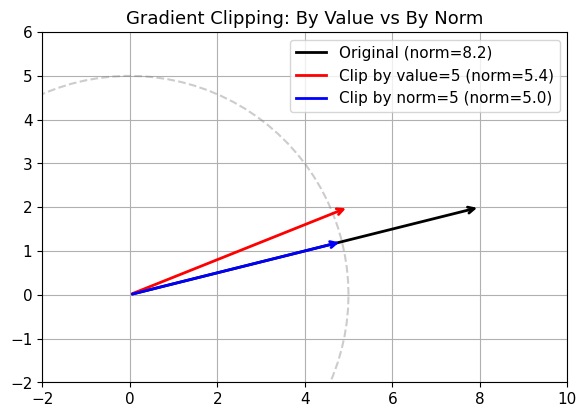

Clip by norm preserves direction; clip by value distorts it.


In [ ]:
# Visualize: clip by value distorts direction, clip by norm preserves it
g = np.array([8.0, 2.0])
g_clip_val = np.clip(g, -5, 5)
g_clip_norm = g * 5.0 / np.linalg.norm(g) if np.linalg.norm(g) > 5 else g

fig, ax = plt.subplots(figsize=(6, 6))
origin = np.array([0, 0])
ax.annotate("", xy=g, xytext=origin,
            arrowprops=dict(arrowstyle="->", color="black", lw=2))
ax.annotate("", xy=g_clip_val, xytext=origin,
            arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.annotate("", xy=g_clip_norm, xytext=origin,
            arrowprops=dict(arrowstyle="->", color="blue", lw=2))

ax.plot([], [], "k-", lw=2, label=f"Original (norm={np.linalg.norm(g):.1f})")
ax.plot([], [], "r-", lw=2, label=f"Clip by value=5 (norm={np.linalg.norm(g_clip_val):.1f})")
ax.plot([], [], "b-", lw=2, label=f"Clip by norm=5 (norm={np.linalg.norm(g_clip_norm):.1f})")

# Draw circle at norm=5
theta_circle = np.linspace(0, 2 * np.pi, 100)
ax.plot(5 * np.cos(theta_circle), 5 * np.sin(theta_circle), "--", color="gray", alpha=0.4)

ax.set_xlim(-2, 10)
ax.set_ylim(-2, 6)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Gradient Clipping: By Value vs By Norm")
plt.tight_layout()
plt.show()
print("Clip by norm preserves direction; clip by value distorts it.")